# ORIE 4820 Capstone Project
## Optimizing Healthcare Insurance Outreach Across New York State Counties

**Objective:** Maximize the number of newly insured low-income individuals (age 21–64, income ≤ 200% FPL) by optimally allocating outreach resources across New York State counties, with an equity constraint ensuring underserved counties receive attention.

**Data Source:** U.S. Census Bureau Small Area Health Insurance Estimates (SAHIE), 2023

In [37]:
# !pip install ortools

In [38]:
import pandas as pd
from ortools.linear_solver import pywraplp
import matplotlib.pyplot as plt
import numpy as np

In [39]:
# read excel file
df = pd.read_excel("NewYork_SAHIE_PivotTable.xlsx", sheet_name="NewYork_SAHIE_Combined")
# df = pd.read_csv("NewYork_SAHIE_PivotTable.csv") # uncomment if using a csv (I'm using excel)

In [40]:
# Filter to county-level rows, low-income adults (≤200% FPL), all races/sexes, year 2023
df = df[
    (df["agecat"] == 5) &       # age 21–64
    (df["racecat"] == 0) &      # all races
    (df["sexcat"] == 0) &       # both sexes
    (df["iprcat"] == 1) &       # low-income (≤200% FPL)
    (df["year"] == 2023) &
    (df["countyfips"] != 0)     # exclude statewide aggregate row
]

# Keep relevant columns
df = df[["countyfips", "county_name", "NUI", "PCTUI", "NIPR"]].copy()

# Parameters
B = 1000          # total budget (resource units)
K = 10            # max counties to target
M = 100           # max allocation per county
k = 10            # effectiveness scaling factor
min_underserved = 3  # minimum underserved counties required (equity constraint)

# Normalize PCTUI (convert from % to fraction)
df["PCTUI"] = df["PCTUI"] / 100.0

# Compute alpha: estimated newly insured per unit of resource allocated
# Counties with higher uninsured rates yield greater marginal impact
df["alpha"] = k * df["PCTUI"]

# Flag underserved counties: uninsured rate strictly above the statewide county median
median_pctui = df["PCTUI"].median()
df["underserved"] = (df["PCTUI"] > median_pctui).astype(int)

print(f"Median county uninsured rate: {median_pctui:.3f}")
print(f"Underserved counties (PCTUI > median): {df['underserved'].sum()} of {len(df)}")

counties = df.index.tolist()

Median county uninsured rate: 0.100
Underserved counties (PCTUI > median): 31 of 62


## LP Model Formulation

**Sets:** $\mathcal{I}$ — New York State counties

**Parameters:** $B$ = budget, $K$ = max counties, $M$ = max allocation per county, $\alpha_i = k \cdot \text{PCTUI}_i$ = effectiveness, $\text{NUI}_i$ = uninsured population, $u_i \in \{0,1\}$ = underserved indicator, $R$ = min underserved counties

**Decision variables:** $x_i \geq 0$ (resource allocation), $y_i \in \{0,1\}$ (county selected)

$$\max \sum_{i \in \mathcal{I}} \alpha_i x_i$$

$$\text{s.t.} \quad \sum_{i \in \mathcal{I}} x_i \leq B$$

$$x_i \leq M y_i \qquad \forall\, i \in \mathcal{I}$$

$$\sum_{i \in \mathcal{I}} y_i \leq K$$

$$x_i \leq \text{NUI}_i \qquad \forall\, i \in \mathcal{I}$$

$$\sum_{i \in \mathcal{I}} u_i y_i \geq R$$

$$y_i \in \{0,1\} \qquad \forall\, i \in \mathcal{I}$$

In [41]:
df.head()

,countyfips,county_name,NUI,PCTUI,NIPR,alpha,underserved
13801,1,Albany County ...,3912,0.100,38990,1.00,1
13897,3,Allegany County ...,642,0.093,6896,0.93,0
13993,5,Bronx County ...,37428,0.110,340919,1.10,1
14089,7,Broome County ...,3182,0.099,32117,0.99,0
14185,9,Cattaraugus County ...,1121,0.088,12775,0.88,0


In [42]:
# CREATE SOLVER
solver = pywraplp.Solver.CreateSolver("gurobi")

# DECISION VARIABLES
x = {}
y = {}

for i in counties:
    x[i] = solver.NumVar(0, M, f"x_{i}")      # resource allocation
    y[i] = solver.BoolVar(f"y_{i}")           # select county

# OBJECTIVE
solver.Maximize(
    solver.Sum(df.loc[i, "alpha"] * x[i] for i in counties)
)

# CONSTRAINTS

# Budget
solver.Add(solver.Sum(x[i] for i in counties) <= B)

# Selection constraint
for i in counties:
    solver.Add(x[i] <= M * y[i])

# Limit number of counties
solver.Add(solver.Sum(y[i] for i in counties) <= K)

# Cannot exceed uninsured population 
for i in counties:
    solver.Add(x[i] <= df.loc[i, "NUI"])

# SOLVE
status = solver.Solve()

# PRINT
if status == pywraplp.Solver.OPTIMAL:
    print("Optimal solution found!\n")

    total_newly_insured = 0

    for i in counties:
        if y[i].solution_value() > 0.5:
            alloc = x[i].solution_value()
            alpha = df.loc[i, "alpha"]
            newly_insured = alpha * alloc

            total_newly_insured += newly_insured

            print(f"{df.loc[i, 'county_name'].strip()}:")
            print(f"  Allocation: {alloc:.2f}")
            print(f"  Estimated newly insured: {newly_insured:.2f}\n")

    print(f"Total newly insured: {total_newly_insured:.2f}")
else:
    print("No optimal solution found.")

Optimal solution found!

Dutchess County:
  Allocation: 100.00
  Estimated newly insured: 126.00

Nassau County:
  Allocation: 100.00
  Estimated newly insured: 135.00

Orange County:
  Allocation: 100.00
  Estimated newly insured: 132.00

Putnam County:
  Allocation: 100.00
  Estimated newly insured: 142.00

Queens County:
  Allocation: 100.00
  Estimated newly insured: 159.00

Rockland County:
  Allocation: 100.00
  Estimated newly insured: 150.00

Suffolk County:
  Allocation: 100.00
  Estimated newly insured: 144.00

Ulster County:
  Allocation: 100.00
  Estimated newly insured: 159.00

Westchester County:
  Allocation: 100.00
  Estimated newly insured: 152.00

Yates County:
  Allocation: 100.00
  Estimated newly insured: 178.00

Total newly insured: 1477.00


In [43]:
# creating a ressults df to compare old vs new pct uninsured after allocation
results = []

for i in counties:
    alloc = x[i].solution_value()
    alpha = df.loc[i, "alpha"]
    z = alpha * alloc

    NUI_old = df.loc[i, "NUI"]
    NIPR = df.loc[i, "NIPR"]

    NUI_new = max(NUI_old - z, 0)
    pct_new = NUI_new / NIPR

    results.append({
        "county": df.loc[i, "county_name"],
        "old_pct": df.loc[i, "PCTUI"],
        "new_pct": pct_new
    })

results_df = pd.DataFrame(results)

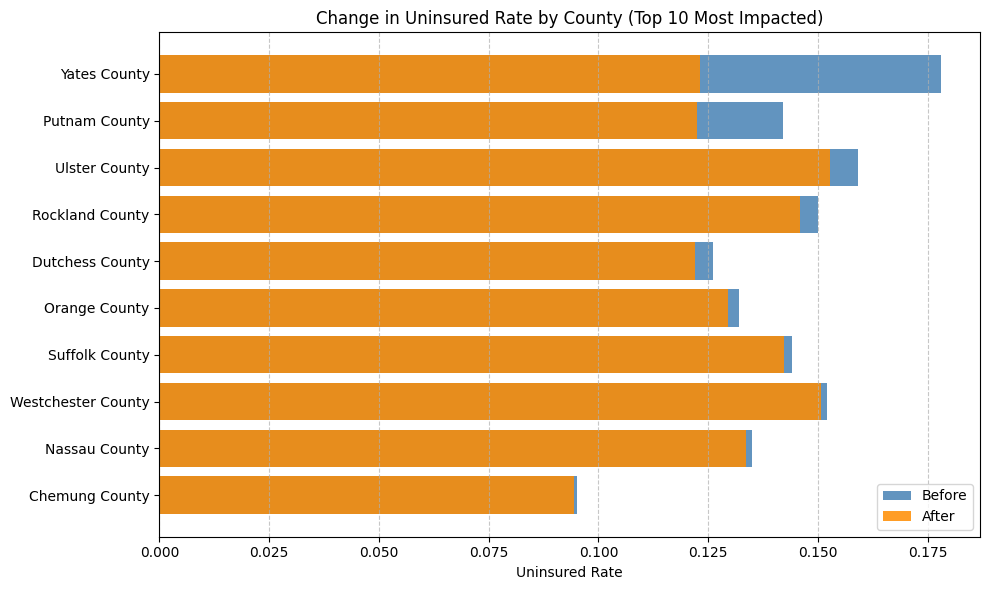

In [44]:
# Clean county names
plot_df = results_df.copy()
plot_df["county"] = plot_df["county"].str.strip()

# Remove blank rows
plot_df = plot_df[plot_df["county"] != ""]

# Compute uninsured rate reduction
plot_df["reduction"] = plot_df["old_pct"] - plot_df["new_pct"]

# Top 10 most impacted counties
plot_df = plot_df.sort_values(by="reduction", ascending=False).head(10)

# Reverse for horizontal bar chart display order
plot_df = plot_df[::-1]

positions = np.arange(len(plot_df))

plt.figure(figsize=(10, 6))

plt.barh(positions, plot_df["old_pct"], label="Before", color="steelblue", alpha=0.85)
plt.barh(positions, plot_df["new_pct"], label="After", color="darkorange", alpha=0.85)

plt.yticks(positions, plot_df["county"])
plt.xlabel("Uninsured Rate")
plt.title("Change in Uninsured Rate by County (Top 10 Most Impacted)")
plt.legend()
plt.grid(axis="x", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()

In [45]:
# export results to csv
results_df.to_csv('results.csv', index=False)
print('results.csv exported successfully!')

results.csv exported successfully!


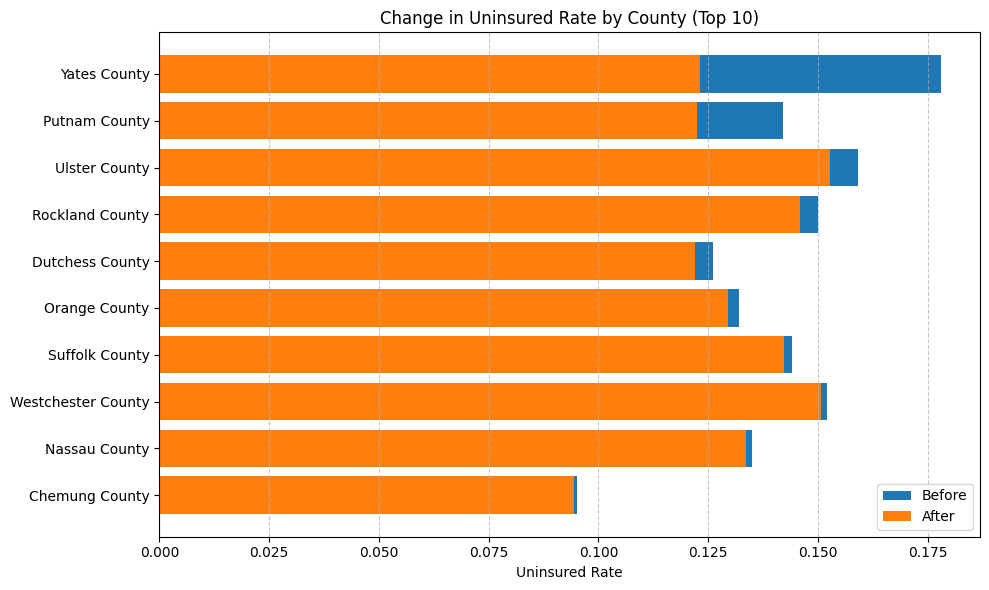

In [46]:
# Clean county names
plot_df = results_df.copy()
plot_df["county"] = plot_df["county"].str.strip()

# Remove any blank rows
plot_df = plot_df[plot_df["county"] != ""]

# Compute reduction
plot_df["reduction"] = plot_df["old_pct"] - plot_df["new_pct"]

# Take top 10 most impacted counties
plot_df = plot_df.sort_values(by="reduction", ascending=False).head(10)

# Reverse for better plotting order
plot_df = plot_df[::-1]

# Positions
y = np.arange(len(plot_df))

# Plot
plt.figure(figsize=(10,6))

plt.barh(y, plot_df["old_pct"], label="Before")
plt.barh(y, plot_df["new_pct"], label="After")

# Labels
plt.yticks(y, plot_df["county"])
plt.xlabel("Uninsured Rate")
plt.title("Change in Uninsured Rate by County (Top 10)")

plt.legend()
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()